In [13]:
import pandas as pd
import numpy as np

items = pd.read_csv("data/items.csv")
sales_train = pd.read_csv('data/sales_train.csv')

print(items['item_category_id'].max())
print(items['item_id'].max())
#sales_train.shape
print((sales_train['item_cnt_day'] <= 0).sum())


83
22169
7356


ЧИСТИМ, ГРУППИРУЕМ И СЖИМАЕМ ДАННЫЕ ЕЩКЕРЕ

In [14]:
monthly = sales_train.groupby(['date_block_num', 'shop_id', 'item_id']).agg(
    item_cnt_month = ('item_cnt_day', 'sum'),
    avg_item_price = ('item_price', 'mean')
).reset_index()

monthly['item_cnt_month'] = monthly['item_cnt_month'].clip(0,20).astype(int)
monthly.head()


,date_block_num,shop_id,item_id,item_cnt_month,avg_item_price
0,0,0,32,6,221.0
1,0,0,33,3,347.0
2,0,0,35,1,247.0
3,0,0,43,1,221.0
4,0,0,51,2,128.5


In [15]:
monthly["date_block_num"] = monthly['date_block_num'].astype('int8')
monthly["shop_id"] = monthly['shop_id'].astype('int8')
monthly["item_id"] = monthly['item_id'].astype('int16')
monthly["item_cnt_month"] = monthly['item_cnt_month'].astype('int8')
monthly["avg_item_price"] = monthly['avg_item_price'].astype('float32')

monthly.dtypes

date_block_num       int8
shop_id              int8
item_id             int16
item_cnt_month       int8
avg_item_price    float32
dtype: object

In [16]:
monthly = monthly[np.isfinite(monthly['avg_item_price'])]

In [17]:
print(f"{monthly.memory_usage(deep=True).sum() / 1024**2:.2f}", "MB")

13.81 MB


ВИЗУАЛИЗИРУЕМ ЧОТО ТАМ, ВСЁ РАВНО НИЧО НЕ ПОЙМУ

<Axes: xlabel='date_block_num'>

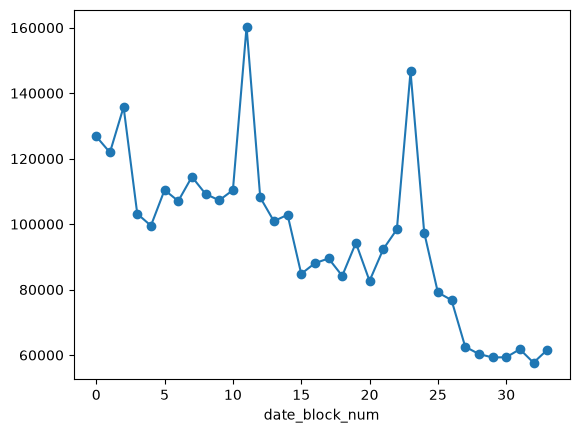

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns


by_month = monthly.groupby('date_block_num')['item_cnt_month'].sum()
by_month.plot(marker='o')

У НИХ В 2015 СПРОС СИЛЬНО УПАЛ, НАВЕРНО СТОИТ БРАТЬ ДАННЫЕ ТОЛЬКО С 27 МЕСЯЦА

<Axes: >

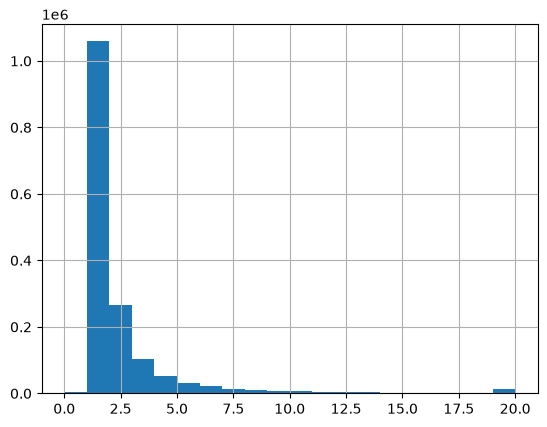

In [19]:
monthly['item_cnt_month'].hist(bins=20)

НАКОНЕЦ-ТО ОБУЧАЕМ МОДЕЕЕЛЬ BASELINE

In [20]:
monthly.head()

,date_block_num,shop_id,item_id,item_cnt_month,avg_item_price
0,0,0,32,6,221.0
1,0,0,33,3,347.0
2,0,0,35,1,247.0
3,0,0,43,1,221.0
4,0,0,51,2,128.5


In [ ]:
train = monthly[monthly['date_block_num'] < 33]
val = monthly[monthly['date_block_num'] == 33]

features = ['shop_id', 'item_id', 'avg_item_price']

x_train = train[features]
y_train = train['item_cnt_month']

x_val = val[features]
y_val = val['item_cnt_month']


In [22]:
from xgboost import XGBRegressor

model = XGBRegressor()

model.fit(x_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


И КОНЕЧНО ЖЕ МЕЕЕЕТРИИИКИИИ😋😋😋

In [23]:
from sklearn.metrics import mean_squared_error

raw = model.predict(x_val)
print((raw < 0).sum())
print((raw>20).sum())

0
0


In [24]:
pred_train = np.clip(model.predict(x_train), 0, 20)
pred_val = np.clip(raw, 0, 20)


rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))

print(rmse_train, rmse_val)

2.419346430774148 2.405338065006708
